# 05b — Custom Datasets in Experiments

By default, `Experiment` loads datasets from the built-in registry (e.g. `"adult"`, `"ricci"`).
You can also pass your own data directly as a dictionary — useful when you have custom preprocessing or external datasets.

## Creating a custom dataset

A custom dataset dict needs three required keys:
- **`name`** — display name used in the results DataFrame
- **`data`** — tuple of `(X, y)` where `X` is a DataFrame and `y` is array-like
- **`sens_attr`** — name of the sensitive attribute column in `X`

And one optional key:
- **`priv_group`** — value of the privileged group (default: `1`)

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from skfair.experimentation import Experiment

# Generate a toy dataset
rng = np.random.RandomState(42)
n = 200

X_custom = pd.DataFrame({
    "income": rng.randn(n),
    "score": rng.randn(n),
    "gender": rng.choice([0, 1], size=n),
})
y_custom = rng.choice([0, 1], size=n)

X_custom.head()

,income,score,gender
0,0.496714,0.357787,0
1,-0.138264,0.560785,0
2,0.647689,1.083051,0
3,1.523030,1.053802,0
4,-0.234153,-1.377669,1


## Running an experiment with a custom dataset

In [ ]:
exp = Experiment(
    datasets=[
        {
            "name": "my_data",
            "data": (X_custom, y_custom),
            "sens_attr": "gender",
            "priv_group": 1,
        },
    ],
    methods=["Baseline", "FairSmote", "Massaging"],
    metrics=["accuracy", "spd"],
    n_splits=2,
    random_state=42,
)

results = exp.run(verbose=True)
results


Dataset: my_data
  Baseline                       | LogReg  acc=0.590  spd=0.324
  FairSmote                      | LogReg  acc=0.540  spd=0.061
  Massaging                      | LogReg  acc=0.590  spd=0.324


,dataset,method,classifier,accuracy,spd
0,my_data,Baseline,LogReg,0.59,0.323544
1,my_data,FairSmote,LogReg,0.54,0.061408
2,my_data,Massaging,LogReg,0.59,0.323544


## Mixing registry and custom datasets

You can mix built-in registry names with custom dicts in the same experiment.

In [3]:
exp_mixed = Experiment(
    datasets=[
        "ricci",                                              # from registry
        {"name": "my_data", "data": (X_custom, y_custom),     # user-provided
         "sens_attr": "gender", "priv_group": 1},
    ],
    methods=["Baseline", "FairSmote"],
    metrics=["accuracy", "spd"],
    n_splits=2,
    random_state=42,
)

results_mixed = exp_mixed.run(verbose=True)
results_mixed


Dataset: Ricci
  Baseline                       | LogReg  acc=0.703  spd=-0.668
  FairSmote                      | LogReg  acc=0.788  spd=-0.065

Dataset: my_data
  Baseline                       | LogReg  acc=0.590  spd=0.324
  FairSmote                      | LogReg  acc=0.540  spd=0.061


,dataset,method,classifier,accuracy,spd
0,Ricci,Baseline,LogReg,0.703390,-0.667959
1,Ricci,FairSmote,LogReg,0.788136,-0.064761
2,my_data,Baseline,LogReg,0.590000,0.323544
3,my_data,FairSmote,LogReg,0.540000,0.061408


## Plugging into ComparisonReport

Results from custom datasets work with `to_report()` just like registry datasets.

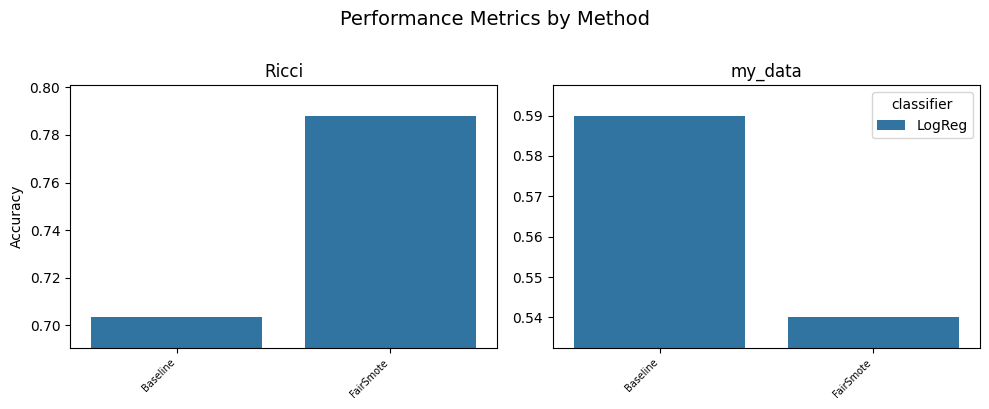

In [4]:
report = exp_mixed.to_report()
report.plot_performance();